# **RAG and SHAP for MRI Sequence Classification**

**Objective:** Demonstrate how Retrieval-Augmented Generation (RAG) improves LLM performance on a radiology task and use SHapley Additive exPlanations (SHAP) to explain which features drive the prediction.

**Task:** Classify brain MRI sequences into one of 6 types based on DICOM Header metadata tags.
- MRI Sequence Types: T1 (Pre/Post), T2 (Pre/Post), FLAIR, ADC

**Why this matters:**
- Small LLMs lack radiology domain-specific knowledge about radiology and MRI physics
- RAG augments the LLM with retrieved similar examples from a knowledge base
    - Allows the model to be <u>grounded within the radiology-context</u>
- SHAP provides interpretability by showing which DICOM tags influence the prediction

**Overview:**
1. Build a FAISS vector index from labeled MRI examples
2. Compare classification performance with vs. without RAG
3. Use SHAP to explain feature importance in the RAG pipeline


### Prerequisites:
- HuggingFace Account and User Access Token
    - [Documentation: Creating HF User Access Tokens](https://huggingface.co/docs/hub/en/security-tokens "HuggingFace Documentation")
- Access to Llama-3.2 Model Family
    - [Confirm Access of HF Model Page](https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct "Llama-3.2-1B-Instruct")


## Imports

In [ ]:
!pip install faiss-cpu
#!pip install transformers
#!pip install sentence-transformers
#!pip install shap


In [ ]:
import os
import torch
import io
from io import StringIO
import json
import pandas as pd
import numpy as np
import faiss
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from sentence_transformers import SentenceTransformer

import shap
import matplotlib.pyplot as plt

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# "/content/drive/MyDrive/"

Mounted at /content/drive


## Set HuggingFace Token
Paste your HuggingFace Token below to download and run the LLMs
- [Documentation for creating and using HuggingFace Tokens](https://huggingface.co/docs/hub/en/security-tokens "HuggingFace Documentation")

In [ ]:
os.environ["HF_TOKEN"] = #INSERT YOUR HUGGINGFACE TOKEN HERE


## Configuration: Retrieval Settings
Paths for the FAISS index and associated metadata, embedding model selection, and retrieval parameters.

In [ ]:
INDEX_PATH = "rag.faiss"
TEXTS_PATH = "rag_texts.csv"
META_PATH  = "faiss_meta.json"
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"
device = "cuda" if torch.cuda.is_available() else "cpu"

TOP_K = 3
TEXT_COL = None
BATCH_SIZE = 64

## Configuration: LLM Settings
Hugging Face model ID and context length safeguard for the language model.
- A maximum context length safegaurd is defined to avoid prompts that are too large.

### Define which LLM model to use
**`Llama-3.2-1B-Instruct`** was used in this notebook due to compute restrictions with Colab, but can be replaced for any (larger) LLMs.
- Make sure HuggingFace account [has access to the Llama-3.2 model family](https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct "Llama-3.2-1B-Instruct")

In [ ]:
MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"
MAX_CONTEXT_CHARS = 8000 #A Safeguard to avoid too large prompts

## RAG Knowledge Base (Dataset)
Define the labeled MRI sequence database containing DICOM header tags and ground-truth classifications. This serves as the retrieval corpus for RAG.
- Below dataset includes 30 studies for the following MRI sequences:
    1. T1 (Pre)
    2. T1 (Post)
    3. T2 (Pre)
    4. T2 (Post)
    5. FLAIR
    6. ADC
- Note that the below corresponds to a synthetic dataset with 5 studies for each sequence type.
- Includes 27 sequence-relevant DICOM tags for each study, including `SeriesDescription`

In [ ]:
RAG_DATABASE_CSV = """SeriesDescription,RepetitionTime,EchoTime,InversionTime,ScanningSequence,ImageType,FlipAngle,EchoTrainLength,ContrastBolusAgent,classification
AXIAL_220,10774,126,2430,IR,ORIGINAL\\PRIMARY\\M_IR\\M\\IR,90,19,,FLAIR
BRAIN AX 220,8792,138,2225,IR,ORIGINAL\\PRIMARY\\M\\ND\\NORM,90,18,,FLAIR
AXIAL_LongTR_5,10394,112,2138,IR,ORIGINAL\\PRIMARY\\M_IR\\M\\IR,90,19,,FLAIR
AXIAL_P3,9516,121,2459,IR,ORIGINAL\\PRIMARY\\M\\ND\\NORM,90,20,,FLAIR
AXIAL_Q5,9447,104,2461,IR,ORIGINAL\\PRIMARY\\M\\ND\\NORM,90,22,,FLAIR
AXIAL_BW_5,6081,87,0,SE,ORIGINAL\\PRIMARY\\AXIAL,90,20,,T2_pre
AX_HEAD_5,6267,113,0,SE,ORIGINAL\\PRIMARY\\AXIAL,90,18,,T2_pre
AXIAL_5mm_STD,5205,105,0,SE,ORIGINAL\\PRIMARY\\AXIAL,90,13,,T2_pre
AXIAL_Quiet_5,6137,100,0,SE,ORIGINAL\\PRIMARY\\AXIAL,90,24,,T2_pre
AX_HEAD_5_T2,4806,120,0,SE,ORIGINAL\\PRIMARY\\AXIAL,90,18,,T2_pre
AX_NS_5mm,1815,2.51,985,IR,ORIGINAL\\PRIMARY\\M\\IR\\GR,15,1,,T1_pre
AXIAL_WIP,2066,3.38,1144,IR,ORIGINAL\\PRIMARY\\AXIAL,16,1,,T1_pre
BRAIN AX 200,654,12,0,SE,ORIGINAL\\PRIMARY\\M_SE\\M\\SE,90,4,,T1_pre
AXIAL_STD_5,511,13,0,SE,ORIGINAL\\PRIMARY\\M_SE\\M\\SE,90,2,,T1_pre
AXIAL_WIP_T1,494,13.2,0,SE,ORIGINAL\\PRIMARY\\M_SE\\M\\SE,90,5,,T1_pre
AXIAL_v2,2286,3.69,885,IR,ORIGINAL\\PRIMARY\\M\\NORM,13,1,Magnevist,T1_post
AXIAL_A2_post,477,7.3,0,SE,ORIGINAL\\PRIMARY\\M_SE\\M\\SE,90,4,Dotarem,T1_post
SURG.PLAN,477,7.3,0,SE,ORIGINAL\\PRIMARY\\M_SE\\M\\SE,90,4,Dotarem,T1_post
AXIAL_STD_5_B,1786,3.56,1017,IR,ORIGINAL\\PRIMARY\\AXIAL,10,1,Gadavist,T1_post
AXIAL_A2_gad,455,13.8,0,SE,ORIGINAL\\PRIMARY\\M_SE\\M\\SE,90,2,Gadavist,T1_post
AXIAL_Quiet_5B,5286,117,0,SE,ORIGINAL\\PRIMARY\\AXIAL,90,14,Dotarem,T2_post
AXIAL_HiRes_5_B,5216,90,0,SE,ORIGINAL\\PRIMARY\\AXIAL,90,13,Dotarem,T2_post
AX_HEAD_5_B,5092,92,0,SE,ORIGINAL\\PRIMARY\\M_SE\\M\\SE,90,19,Gadavist,T2_post
AXIAL_HiRes_B2,5519,112,0,SE,ORIGINAL\\PRIMARY\\M_SE\\M\\SE,90,19,Magnevist,T2_post
AX_HEAD_5_B2,4658,86,0,SE,ORIGINAL\\PRIMARY\\M_SE\\M\\SE,90,17,Gadavist,T2_post
AXIAL_Param_B,4731,94,0,EP,DERIVED\\PRIMARY\\DIFFUSION\\ADC\\MAP,90,1,,ADC
AXIAL_MAP_A,6299,68.6,0,EP,DERIVED\\PRIMARY\\ADC\\MAP,90,1,,ADC
AXIAL_Kurt_A,6992,84.4,0,EP,DERIVED\\PRIMARY\\DIFFUSION\\ADC\\MAP,90,1,,ADC
AXIAL_Param_B2,6194,71,0,EP,DERIVED\\PRIMARY\\DIFFUSION\\ADC\\MAP,90,1,,ADC
AXIAL_MAP_5,6470,85.7,0,EP,DERIVED\\PRIMARY\\ADC\\MAP,90,1,,ADC"""


In [ ]:
rag_df = pd.read_csv(StringIO(RAG_DATABASE_CSV))
print(f"\033[1mRAG database: {len(rag_df)} studies\033[0m")
print(f"\n\tClasses: {rag_df['classification'].unique().tolist()}")


RAG database: 30 studies

	Classes: ['FLAIR', 'T2_pre', 'T1_pre', 'T1_post', 'T2_post', 'ADC']


## Build FAISS Vector Index
Convert each database row into a text representation, encode using a sentence transformer, L2-normalize the embeddings, and build a FAISS inner-product index for fast similarity search.

In [ ]:
def build_text_column(df: pd.DataFrame, text_col: str | None = None) -> pd.Series:
    """
    Builds a 'CombinedFeatures' text by joining all columns as 'col: value'.
    """
    if text_col and text_col in df.columns:
        s = df[text_col].fillna("").astype(str)
        s = s.apply(lambda x: x.strip())
        return s

    def row_to_text(row):
        parts = []
        for col, val in row.items():
            if pd.isna(val):
                continue
            sval = str(val).strip()
            if sval == "":
                continue
            parts.append(f"{col}: {sval}")
        return ", ".join(parts)

    combined = df.apply(row_to_text, axis=1)
    return combined

In [ ]:
#Load database
df = pd.read_csv(StringIO(RAG_DATABASE_CSV))
#Build the text column
texts = build_text_column(df, TEXT_COL)
texts = texts.fillna("").astype(str).tolist()

#Load embedding model
embedding_model = SentenceTransformer(EMBED_MODEL_NAME)
embedding_model = embedding_model.to(device)

#Encode (batched), get float32, L2-normalize
embeddings = []
for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i+BATCH_SIZE]
    vecs = embedding_model.encode(
        batch,
        convert_to_numpy=True,
        normalize_embeddings=False,  # we'll normalize manually
        batch_size=min(BATCH_SIZE, len(batch)),
        device=device
    )
    embeddings.append(vecs.astype("float32"))

embeddings = np.vstack(embeddings)

# L2-normalize to use Inner Product (cosine similarity equivalent post-normalization)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1.0
embeddings = embeddings / norms

#Build FAISS index (Inner Product on unit vectors)
dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings)

#Save index + texts (id,text) for later retrieval
faiss.write_index(index, INDEX_PATH)
pd.DataFrame({"id": np.arange(len(texts)), "text": texts}).to_csv(TEXTS_PATH, index=False)

print("\033[1mFAISS index built and saved.\033[0m")
print(f"\t• items: {len(texts)}")
print(f"\t• dim:   {dim}")
print(f"\t• index: {INDEX_PATH}")
print(f"\t• texts: {TEXTS_PATH}")
print(f"\t• meta:  faiss_meta.json")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FAISS index built and saved.
	• items: 30
	• dim:   384
	• index: rag.faiss
	• texts: rag_texts.csv
	• meta:  faiss_meta.json


## Load FAISS Index
Load the pre-built FAISS index and associated text mappings from disk. Read metadata to ensure we use the same embedding model that created the index.

In [ ]:
#Load FAISS index/texts:
if not os.path.exists(INDEX_PATH):
    raise FileNotFoundError(f"FAISS index not found at {INDEX_PATH}")
if not os.path.exists(TEXTS_PATH):
    raise FileNotFoundError(f"Texts CSV not found at {TEXTS_PATH}")

index = faiss.read_index(INDEX_PATH)
texts_df = pd.read_csv(TEXTS_PATH)
if not {"id", "text"}.issubset(texts_df.columns):
    raise ValueError("texts CSV must have columns: id, text")
id_to_text = texts_df.set_index("id")["text"].to_dict()

In [ ]:
#Reading meta for embedding model (to match the index)
meta = {}
if os.path.exists(META_PATH):
    try:
        with open(META_PATH, "r") as f:
            meta = json.load(f)
    except Exception:
        pass

if EMBED_MODEL_NAME is None:
    EMBED_MODEL_NAME = meta.get("embedding_model", "all-MiniLM-L6-v2")

## Load Language Model
Load the instruction-tuned LLM (`Llama-3.2-1B-Instruct`) with appropriate dtype for GPU inference and create a text-generation pipeline.

In [ ]:
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
print(f"Using device: {device}, dtype: {dtype}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=dtype, device_map="auto")
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)
print(f"\033[1mModel loaded\033[0m: {MODEL_ID}")

Using device: cuda, dtype: torch.bfloat16


`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0


Model loaded: meta-llama/Llama-3.2-1B-Instruct


## Embedding Model & Retrieval Function
Load the sentence transformer `all-MiniLM-L6-v2`, encode the database entries, build the FAISS index in-memory, and define the `retrieve_similar()` function that returns the top-k most similar examples for a given query.

In [ ]:
embed_model = SentenceTransformer('all-MiniLM-L6-v2').to(device)

def row_to_text_all_cols(row):
    """Join ALL columns as 'col: value' - your original approach."""
    parts = []
    for col, val in row.items():
        if pd.isna(val):
            continue
        sval = str(val).strip()
        if sval == "":
            continue
        parts.append(f"{col}: {sval}")
    return ", ".join(parts)

#Build text for each row
db_texts = rag_df.apply(row_to_text_all_cols, axis=1).tolist()

#Encode w/ L2 normalization (cosine similarity via inner product)
embeddings = embed_model.encode(
    db_texts,
    convert_to_numpy=True,
    normalize_embeddings=False,
    device=device
).astype('float32')

In [ ]:
#Manual L2 normalization
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
norms[norms == 0] = 1.0
embeddings = embeddings / norms

#Build FAISS index:
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)

In [ ]:
def retrieve_similar(query_text, k=3):
    """Retrieve k most similar examples with distances."""
    query_emb = embed_model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=False,
        device=device
    ).astype('float32')
    # Normalize query
    query_emb = query_emb / np.linalg.norm(query_emb, axis=1, keepdims=True)

    distances, indices = index.search(query_emb, k)
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        results.append({
            'text': db_texts[idx],
            'label': rag_df.iloc[idx]['classification'],
            'distance': float(dist)  # cosine similarity (higher = more similar)
        })
    return results

print(f"FAISS index: {index.ntotal} vectors, dim={embeddings.shape[1]}")

FAISS index: 30 vectors, dim=384


## Define Test Case: FLAIR
Define a FLAIR test case to be used to assess whether RAG can retrieve relevant examples to guide classification.

In [ ]:
# FLAIR test case
TEST_CASE = {
    'SeriesDescription': 'AXIAL_BRAIN_5',
    'RepetitionTime': 9500,
    'EchoTime': 118,
    'InversionTime': 2280,
    'ScanningSequence': 'IR',
    'ImageType': 'ORIGINAL\\PRIMARY\\M\\ND\\NORM',
    'FlipAngle': 90,
    'EchoTrainLength': 17,
    'ContrastBolusAgent': '',
}

GROUND_TRUTH = "FLAIR"

<a id='RAG_Classification'></a>
## **Classification:** With vs. Without RAG
Define classification functions for both approaches and compare results:
- **Without RAG:** LLM classifies using only the input DICOM tags
- **With RAG:** LLM receives retrieved similar examples as context before classifying

In [ ]:
VALID_CLASSES = ["T1_pre", "T1_post", "T2_pre", "T2_post", "FLAIR", "ADC"]

In [ ]:
def test_case_to_text(test_case):
    """Convert test case to text"""
    parts = []
    for col, val in test_case.items():
        if val is None or val == '':
            continue
        parts.append(f"{col}: {val}")
    return ", ".join(parts)

test_text = test_case_to_text(TEST_CASE)
print(f"Test case text:\n{test_text}\n")

def classify_without_rag(test_text):
    prompt = f"""Classify this MRI sequence. Output ONLY one class name.
Classes: {', '.join(VALID_CLASSES)}

{test_text}

Classification:"""
    out = generator(prompt, max_new_tokens=10, do_sample=False,
                    pad_token_id=tokenizer.pad_token_id, return_full_text=False)
    resp = out[0]['generated_text'].strip()
    pred = resp.split()[0].strip('.,;:!?') if resp else "UNKNOWN"
    return pred, resp

def classify_with_rag(test_text, k=3):
    retrieved = retrieve_similar(test_text, k=k)
    examples = "\n".join([f"  - {r['text']}" for r in retrieved])

    prompt = f"""Classify this MRI sequence using similar examples as reference.
Output ONLY one class name.
Classes: {', '.join(VALID_CLASSES)}

Similar examples from database:
{examples}

Target to classify:
{test_text}

Classification:"""
    out = generator(prompt, max_new_tokens=10, do_sample=False,
                    pad_token_id=tokenizer.pad_token_id, return_full_text=False)
    resp = out[0]['generated_text'].strip()
    pred = resp.split()[0].strip('.,;:!?') if resp else "UNKNOWN"
    return pred, resp, retrieved

print(f"\033[1mTest case ready\033[0m (Ground Truth: {GROUND_TRUTH})")


Test case text:
SeriesDescription: AXIAL_BRAIN_5, RepetitionTime: 9500, EchoTime: 118, InversionTime: 2280, ScanningSequence: IR, ImageType: ORIGINAL\PRIMARY\M\ND\NORM, FlipAngle: 90, EchoTrainLength: 17

Test case ready (Ground Truth: FLAIR)


In [ ]:
print("-"*60)
print("WITHOUT RAG")
print("-"*60)
pred_no_rag, resp_no_rag = classify_without_rag(test_text)
print(f"Prediction: {pred_no_rag} {'✓' if pred_no_rag == GROUND_TRUTH else '✗'}")
print(f"Raw output: {repr(resp_no_rag)}")

print("\n" + "-"*60)
print("WITH RAG")
print("-"*60)
pred_rag, resp_rag, retrieved = classify_with_rag(test_text, k=3)
print("Retrieved examples (with cosine similarity):")
for r in retrieved:
    print(f"  [{r['distance']:.4f}] {r['label']}: {r['text'][:55]}...")

print(f"\nPrediction: {pred_rag} {'✓' if pred_rag == GROUND_TRUTH else '✗'}")
print(f"Raw output: {repr(resp_rag)}")

print("\n" + "="*70)
print(f"RESULT: Ground Truth = {GROUND_TRUTH}")
print(f"  Without RAG: {pred_no_rag} {'✓' if pred_no_rag == GROUND_TRUTH else '✗'}")
print(f"  With RAG:    {pred_rag} {'✓' if pred_rag == GROUND_TRUTH else '✗'}")
if pred_rag == GROUND_TRUTH and pred_no_rag != GROUND_TRUTH:
    print("\n\033[1mRAG IMPROVED THE RESULT!\033[0m")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


------------------------------------------------------------
WITHOUT RAG
------------------------------------------------------------
Prediction: T1_pre ✗
Raw output: 'T1_pre\n\nExplanation: The sequence is a'

------------------------------------------------------------
WITH RAG
------------------------------------------------------------
Retrieved examples (with cosine similarity):
  [0.9080] FLAIR: SeriesDescription: AXIAL_P3, RepetitionTime: 9516, Echo...
  [0.8989] FLAIR: SeriesDescription: AXIAL_Q5, RepetitionTime: 9447, Echo...
  [0.8852] T1_pre: SeriesDescription: AXIAL_WIP, RepetitionTime: 2066, Ech...

Prediction: FLAIR ✓
Raw output: 'FLAIR\n\nExplanation:\nThe classification of the given'

RESULT: Ground Truth = FLAIR
  Without RAG: T1_pre ✗
  With RAG:    FLAIR ✓

RAG IMPROVED THE RESULT!


## RAG Results:
- **Without RAG**: `Llama-3.2-1B-Instruct` model incorrectly predicted MRI sequence to be T1 pre-contrast
- **WITH RAG**: Model is able to correctly predict FLAIR as the MRI sequence

## **SHAP Explainability**

**SHAP** (SHapley Additive exPlanations) explains predictions by computing each "feature's" contribution (using game-theoretic Shapley values).

- **Core idea:** Test all possible combinations of features, measure how adding each feature changes the prediction, then average the contributions fairly
- **In our setup:** Features are DICOM tags; the model is the full RAG system (retrieval + LLM); SHAP values show each tag's impact on the FLAIR prediction
- **Technical Implementation:** We use `KernelSHAP`, which approximates Shapley values by sampling feature subsets and fitting a weighted linear model. This makes it tractable for more "black-box" models

### Interpreting results:
- Positive SHAP value → feature pushes toward FLAIR
- Negative SHAP value → feature pushes away from FLAIR

In [ ]:
#Define the features (DICOM tags) we want to explain
FEATURE_NAMES = ['RepetitionTime', 'EchoTime', 'InversionTime', 'ScanningSequence',
                 'ImageType', 'FlipAngle', 'EchoTrainLength']

#Extract feature values from test case
feature_values = [str(TEST_CASE.get(f, '')) for f in FEATURE_NAMES]

def build_text_from_mask(mask):
    """Build DICOM text string from binary mask (1=include, 0=exclude)."""
    parts = []
    for i, include in enumerate(mask):
        if include == 1 and feature_values[i]:
            parts.append(f"{FEATURE_NAMES[i]}: {feature_values[i]}")
    return ", ".join(parts) if parts else "No features"

def predict_proba(masks):
    """
    Prediction function for SHAP.
    Input: array of binary masks (N x num_features)
    Output: array of probabilities (N,) for FLAIR class
    """
    results = []
    for mask in masks:
        text = build_text_from_mask(mask)

        # Get RAG prediction
        retrieved = retrieve_similar(text, k=3)
        examples = "\n".join([f"  - {r['text']}" for r in retrieved])

        prompt = f"""Classify this MRI sequence. Output ONLY one class name.
Classes: {', '.join(VALID_CLASSES)}

Similar examples:
{examples}

Target:
{text}

Classification:"""

        out = generator(prompt, max_new_tokens=10, do_sample=False,
                        pad_token_id=tokenizer.pad_token_id, return_full_text=False)
        pred = out[0]['generated_text'].strip().split()[0].strip('.,;:!?')

        # Convert to probability (1.0 if FLAIR, 0.0 otherwise)
        prob_flair = 1.0 if pred == "FLAIR" else 0.0
        results.append(prob_flair)

    return np.array(results)

#Create baseline (no features) and all features input
baseline = np.zeros((1, len(FEATURE_NAMES)))
test_input = np.ones((1, len(FEATURE_NAMES)))

#SHAP KernelExplainer
print("Running SHAP analysis (Note: this may take a minute...)")
explainer = shap.KernelExplainer(predict_proba, baseline)

#SHAP values for our test case
shap_values = explainer.shap_values(test_input, nsamples=50)

#Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_flair = shap_values[0][0] if len(shap_values[0].shape) > 1 else shap_values[0]
else:
    shap_flair = shap_values[0] if len(shap_values.shape) > 1 else shap_values

#1D shape:
shap_flair = np.array(shap_flair).flatten()

print("\n\033[1mSHAP analysis complete!\033[0m")
print(f"\nSHAP values for FLAIR prediction:")
for fname, sval in zip(FEATURE_NAMES, shap_flair):
    direction = "→ \033[1mFLAIR\033[0m" if sval > 0 else "→ other"
    print(f"\t{fname:20s}: {sval:+.3f} {direction}")

Running SHAP analysis (Note: this may take a minute...)


100%|██████████| 1/1 [00:09<00:00,  9.45s/it]


SHAP analysis complete!

SHAP values for FLAIR prediction:
	RepetitionTime      : -0.644 → other
	EchoTime            : -0.452 → other
	InversionTime       : +0.067 → FLAIR
	ScanningSequence    : -0.021 → other
	ImageType           : +0.058 → FLAIR
	FlipAngle           : +0.258 → FLAIR
	EchoTrainLength     : -0.265 → other


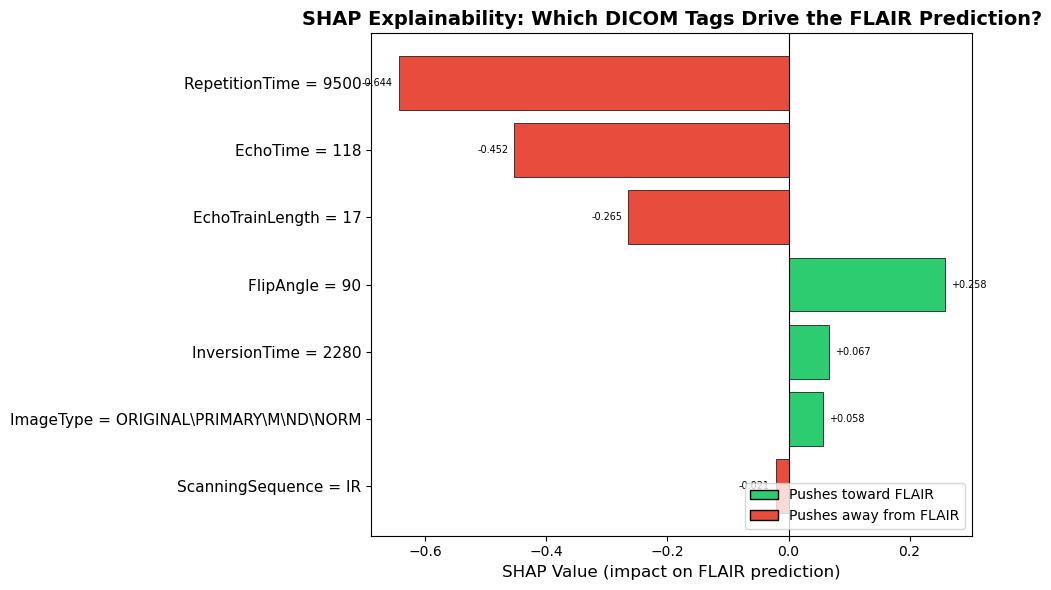

In [ ]:
# VISUALIZATION: SHAP Feature Importance Bar Chart

#Sort:
sorted_indices = np.argsort(np.abs(shap_flair))[::-1]
sorted_names = [FEATURE_NAMES[i] for i in sorted_indices]
sorted_values = [shap_flair[i] for i in sorted_indices]
sorted_feature_vals = [feature_values[i] for i in sorted_indices]

#Create figure (horizontal bar chart)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in sorted_values]
bars = ax.barh(range(len(sorted_names)), sorted_values, color=colors, edgecolor='black', linewidth=0.5)

ylabels = [f"{name} = {val}" for name, val in zip(sorted_names, sorted_feature_vals)]
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(ylabels, fontsize=11)
ax.invert_yaxis()

ax.set_xlabel('SHAP Value (impact on FLAIR prediction)', fontsize=12)
ax.set_title('SHAP Explainability: Which DICOM Tags Drive the FLAIR Prediction?', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')

#Value Labels:
for i, (bar, val) in enumerate(zip(bars, sorted_values)):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, i, f'{val:+.3f}', va='center', ha=ha, fontsize=7)

#Chart Legend::
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Pushes toward FLAIR'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Pushes away from FLAIR')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## SHAP Explainability for RAG

**What SHAP measures here:**

In a RAG system, <u>SHAP captures the combined effect</u> of each feature on:
1. **Retrieval**: which similar examples are pulled from the knowledge base
2. **LLM reasoning**: how the model uses those examples to classify

### Interpreting the results:

| SHAP Value | Meaning |
|------------|---------|
| **Positive** (e.g., InversionTime +0.258) | Removing this tag *hurts* the FLAIR prediction → tag is critical for correct retrieval |
| **Negative** (e.g., RepetitionTime -0.644) | Removing this tag *does not hurt* → other tags compensate in retrieval |

**Key insights:**
- `InversionTime` and `FlipAngle` have positive SHAP values → these are the critical tags that drive retrieval of FLAIR examples